##  Bibliotecas:

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Ler dataframe

In [5]:
s1 = pd.read_excel(r"C:\Users\sensix\Desktop\TESTE_SRICPT\TESTE_SRICPT\SCRIPT_NDVI_PREDICTION\ndvi_prediction_sentinel_123\SENTINEL1.xlsx")
s1["CR"] = (s1["VH"] / s1["VV"])
s1 = s1[s1["ID"]== 2]

s2 = pd.read_excel(r"C:\Users\sensix\Desktop\TESTE_SRICPT\TESTE_SRICPT\SCRIPT_NDVI_PREDICTION\ndvi_prediction_sentinel_123\SENTINEL2.xlsx")
s2["NDVI_S2"] = (s2["B8"] - s2["B4"]) / (s2["B8"] + s2["B4"])
s2 = s2[s2["ID"]== 2]

s3 = pd.read_excel(r"C:\Users\sensix\Desktop\TESTE_SRICPT\TESTE_SRICPT\SCRIPT_NDVI_PREDICTION\ndvi_prediction_sentinel_123\SENTINEL3.xlsx")
s3["NDVI_S3"] = ((s3["Oa17_radiance"]/0.00493004) - (s3["Oa08_radiance"]/0.00876539)) / ((s3["Oa17_radiance"]/0.00493004) + (s3["Oa08_radiance"]/0.00876539))
s3 = s3[s3["ID"]== 2]
s3

,Unnamed: 0,Oa01_radiance,Oa02_radiance,Oa03_radiance,Oa04_radiance,Oa05_radiance,Oa06_radiance,Oa07_radiance,Oa08_radiance,Oa09_radiance,...,Oa17_radiance,Oa18_radiance,Oa19_radiance,Oa20_radiance,Oa21_radiance,quality_flags,cena,ID,data,NDVI_S3
728,0,-2.046431e+09,136.187578,148.661679,156.276615,151.123556,145.777697,136.101254,116.998534,110.288770,...,214.464190,182.972605,175.733727,100.638358,24.236788,2.248536e+09,S3A_20220101T125403_20220101T125703_0,2,2022-01-01,0.530415
729,2,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000e+00,S3A_20220102T122753_20220102T123053_0,2,2022-01-02,NaN
730,4,-2.139826e+09,96.528170,101.905866,100.047438,88.189420,83.242517,79.478130,60.754337,54.041405,...,197.966756,169.641001,162.583997,91.623879,21.164392,2.155141e+09,S3A_20220105T125019_20220105T125319_0,2,2022-01-05,0.705598
731,6,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000e+00,S3A_20220106T122408_20220106T122708_0,2,2022-01-06,NaN
732,8,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000e+00,S3A_20220108T131246_20220108T131546_0,2,2022-01-08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,1626,-2.143289e+09,65.662966,67.304547,61.394991,48.358070,44.819672,43.915134,28.714357,23.552114,...,187.863162,163.555689,157.782948,93.220648,17.740105,2.151678e+09,S3B_20231218T125228_20231218T125528_0,2,2023-12-18,0.841675
1452,1630,-2.009072e+09,296.311892,337.228939,373.186180,385.074360,379.652904,347.578084,318.800894,307.457817,...,272.816888,226.204221,219.069060,152.218932,64.326736,2.285896e+09,S3B_20231222T124844_20231222T125144_0,2,2023-12-22,0.206822
1453,1635,-2.067450e+09,145.433486,160.516761,168.269702,163.082714,158.526950,145.452865,127.202895,121.258905,...,184.447118,156.561480,150.978856,96.174872,33.198731,2.227517e+09,S3B_20231226T124458_20231226T124758_0,2,2023-12-26,0.441040
1454,1639,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000e+00,S3B_20231229T130724_20231229T131024_0,2,2023-12-29,NaN


## Tratar dados:

In [6]:
s1['data'] = pd.to_datetime(s1['data'])
s2['data'] = pd.to_datetime(s2['data'])
s3['data'] = pd.to_datetime(s3['data'])

# Combinar os dataframes com base na coluna de data
df = pd.merge(s1[['data', 'CR']], s2[['data', 'NDVI_S2']], on='data', how='outer')
df = pd.merge(df, s3[['data', 'NDVI_S3']], on='data', how='outer')

# Ordenar o dataframe pela data
df = df.sort_values(by='data')
df = df.fillna(method='ffill').fillna(method='bfill')
df ["DJ"]=  df['data'].dt.strftime('%j').astype(int)
df

,data,CR,NDVI_S2,NDVI_S3,DJ
191,2022-01-01,1.826625,0.732928,0.530415,1
192,2022-01-02,1.826625,0.732928,0.530415,2
551,2022-01-03,1.826625,0.732928,0.517157,3
58,2022-01-04,1.826625,0.732928,0.424022,4
0,2022-01-05,1.826625,0.732928,0.705598,5
...,...,...,...,...,...
57,2023-12-26,1.842474,0.905232,0.441040,360
549,2023-12-27,1.842474,0.905232,0.811184,361
550,2023-12-28,1.842474,0.905232,0.811184,362
727,2023-12-29,1.842474,0.905232,0.811184,363


## CR Escalonado

In [7]:
# função planet
def scale_cr(CR):
    a = 0.99e-11
    b = 0.396
    c = 27.4
    d = 1.78e-02
    m = 1.91e-01
    z = 1.845
    n = 2.50
    k = 5.00e-01
    
    if CR < 1.546:
        return a * (np.exp(b * CR + c)) + d
    elif 1.546 <= CR < 1.729:
        return m * CR + z
    else:
        return 1 - ((1 - k) / (np.exp(n * ((m * CR + z) - k))))
#df['CR_scaled'] = df['CR'].apply(scale_cr)

# Função para aplicar a normalização Min-Max
def min_max_scale(cr):
    cr_min = df['CR'].min()
    cr_max = df['CR'].max()

    return (cr - cr_min) / (cr_max - cr_min)
    
# Aplicar a normalização Min-Max a cada valor de CR
df['CR_scaled'] = df['CR'].apply(lambda cr: min_max_scale(cr))
df

,data,CR,NDVI_S2,NDVI_S3,DJ,CR_scaled
191,2022-01-01,1.826625,0.732928,0.530415,1,0.618426
192,2022-01-02,1.826625,0.732928,0.530415,2,0.618426
551,2022-01-03,1.826625,0.732928,0.517157,3,0.618426
58,2022-01-04,1.826625,0.732928,0.424022,4,0.618426
0,2022-01-05,1.826625,0.732928,0.705598,5,0.618426
...,...,...,...,...,...,...
57,2023-12-26,1.842474,0.905232,0.441040,360,0.637262
549,2023-12-27,1.842474,0.905232,0.811184,361,0.637262
550,2023-12-28,1.842474,0.905232,0.811184,362,0.637262
727,2023-12-29,1.842474,0.905232,0.811184,363,0.637262


## Serie Temporal

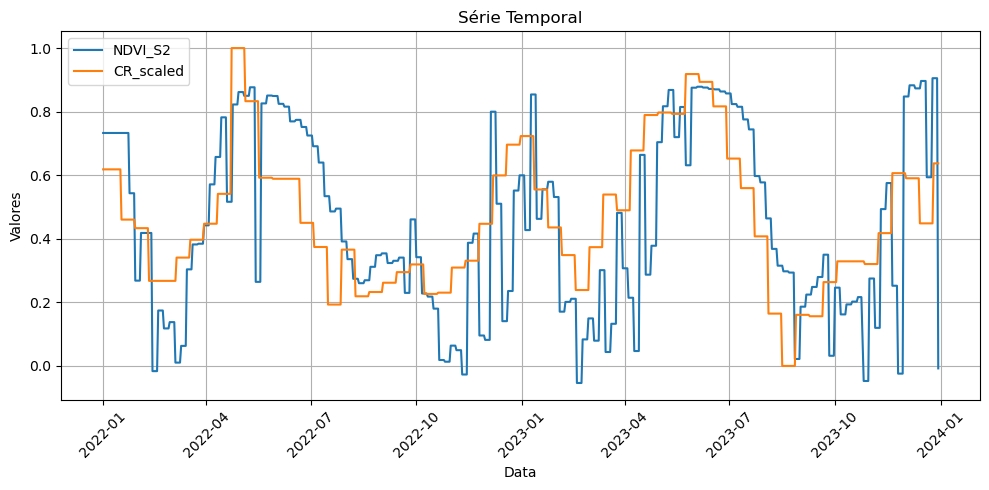

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df['data'], df['NDVI_S2'], label='NDVI_S2')
#plt.plot(df['data'], df['NDVI_S3'], label='NDVI_S3')
plt.plot(df['data'], df['CR_scaled'], label='CR_scaled')
#plt.plot(df['data'], df['CR'], label='CR')

plt.xlabel('Data')
plt.ylabel('Valores')
plt.title('Série Temporal')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Regressão Linear

Equação da Regressão Linear:
NDVI_S2 = 0.8308 * CR_scaled + 0.0619
R²: 0.3998
Erro Médio Quadrático (MSE): 0.0487
Erro Médio Quadrático (RMSE): 0.2208


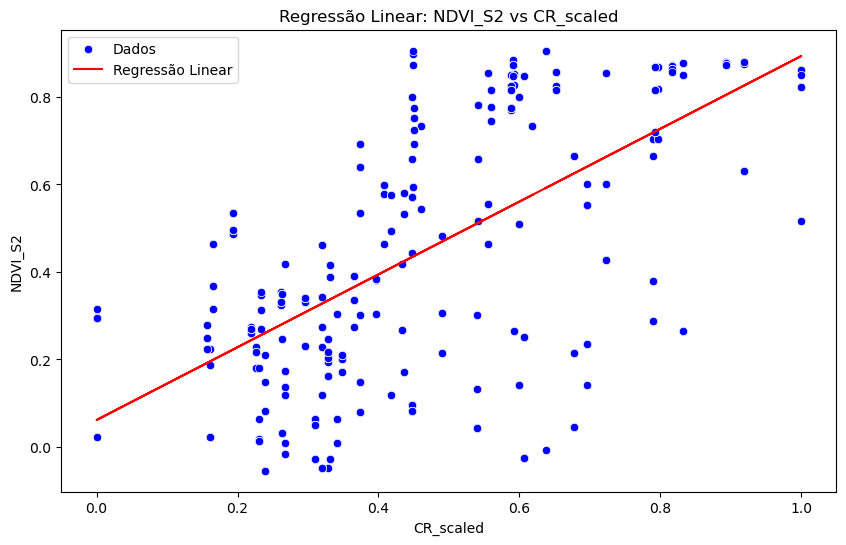

In [14]:
# Separar variáveis independentes e dependentes
X = df[['CR_scaled']]
y = df['NDVI_S2']

# Ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Fazer previsões
y_pred = model.predict(X)

# Coeficientes
slope = model.coef_[0]
intercept = model.intercept_

# Equação da regressão
equation = f"NDVI_S2 = {slope:.4f} * CR_scaled + {intercept:.4f}"
print("Equação da Regressão Linear:")
print(equation)

# Calcular R²
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.4f}")

# Calcular erro médio quadrático
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
print(f"Erro Médio Quadrático (MSE): {mse:.4f}")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")

# Plotar os dados e a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CR_scaled', y='NDVI_S2', data=df, color='blue', label='Dados')
plt.plot(df['CR_scaled'], y_pred, color='red', label='Regressão Linear')

plt.title('Regressão Linear: NDVI_S2 vs CR_scaled')
plt.xlabel('CR_scaled')
plt.ylabel('NDVI_S2')
plt.legend()
plt.show()

## Regressão Polinomial

Equação da Regressão Polinomial:
NDVI_S2 = 19.5514 + -35.7599 * CR_scaled^1 + 21.4691 * CR_scaled^2 + -4.1431 * CR_scaled^3
R²: 0.4193
Erro Médio Quadrático (MSE): 0.0472
Erro Médio Quadrático (RMSE): 0.2172


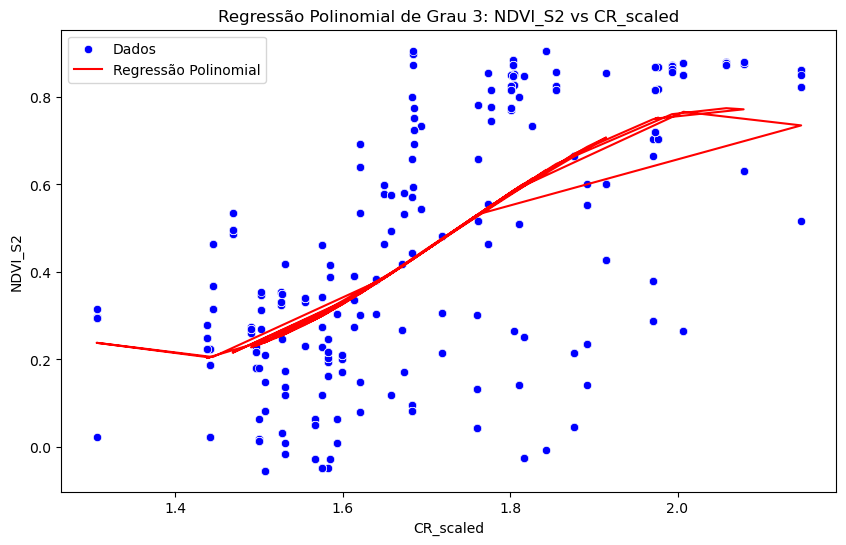

In [25]:
# Separar variáveis independentes e dependentes
X = df[['CR']]
y = df['NDVI_S2']

# Criar características polinomiais de grau 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Ajustar o modelo de regressão linear com características polinomiais
model = LinearRegression()
model.fit(X_poly, y)

# Fazer previsões
y_pred = model.predict(X_poly)

# Coeficientes da equação polinomial
coefficients = model.coef_
intercept = model.intercept_
equation = f"NDVI_S2 = {intercept:.4f}"
for i, coef in enumerate(coefficients[1:], start=1):
    equation += f" + {coef:.4f} * CR_scaled^{i}"
print("Equação da Regressão Polinomial:")
print(equation)

# Calcular R²
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.4f}")

# Calcular erro médio quadrático
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
print(f"Erro Médio Quadrático (MSE): {mse:.4f}")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")

# Plotar os dados e a linha de regressão polinomial
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CR', y='NDVI_S2', data=df, color='blue', label='Dados')
plt.plot(df['CR'], y_pred, color='red', label='Regressão Polinomial')

plt.title('Regressão Polinomial de Grau 3: NDVI_S2 vs CR_scaled')
plt.xlabel('CR_scaled')
plt.ylabel('NDVI_S2')
plt.legend()
plt.show()

## Regressão Polinomial com s3

Equação da Regressão Polinomial:
NDVI_S2 = 7.0658 + 0.0000 * 1 + -17.5351 * CR + 17.8511 * NDVI_S3 + 13.3462 * CR^2 + -24.9461 * CR NDVI_S3 + 13.0188 * NDVI_S3^2 + -3.1515 * CR^3 + 8.1851 * CR^2 NDVI_S3 + -5.9929 * CR NDVI_S3^2 + -1.2089 * NDVI_S3^3
R²: 0.6403
Erro Médio Quadrático (MSE): 0.0292
Erro Médio Quadrático (RMSE): 0.1709


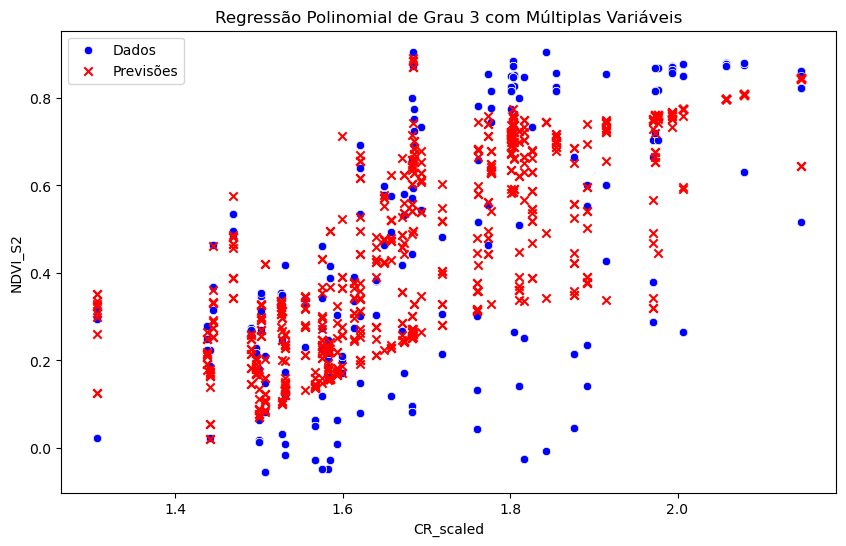

In [28]:
# Separar variáveis independentes e dependentes
X = df[['CR', 'NDVI_S3']]
y = df['NDVI_S2']

# Criar características polinomiais de grau 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Ajustar o modelo de regressão linear com características polinomiais
model = LinearRegression()
model.fit(X_poly, y)

# Fazer previsões
y_pred = model.predict(X_poly)

# Coeficientes da equação polinomial
coefficients = model.coef_
intercept = model.intercept_
terms = poly.get_feature_names_out(['CR', 'NDVI_S3'])
equation = f"NDVI_S2 = {intercept:.4f} " + " ".join(
    f"+ {coef:.4f} * {term}" for coef, term in zip(coefficients, terms)
)

print("Equação da Regressão Polinomial:")
print(equation)

# Calcular R²
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.4f}")

# Calcular erro médio quadrático
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
print(f"Erro Médio Quadrático (MSE): {mse:.4f}")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")

# Plotar os dados e as previsões
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CR', y='NDVI_S2', data=df, color='blue', label='Dados')
plt.scatter(df['CR'], y_pred, color='red', label='Previsões', marker='x')

plt.title('Regressão Polinomial de Grau 3 com Múltiplas Variáveis')
plt.xlabel('CR_scaled')
plt.ylabel('NDVI_S2')
plt.legend()
plt.show()